In [1]:
# ---------------------------
# Task 1: Data Inspection
# ---------------------------

import pandas as pd

# Load datasets
aqi = pd.read_csv("city_day.csv")
crop = pd.read_csv("crop_production.csv")

print("AQI DATASET OVERVIEW")
print("-" * 40)
print("Shape:", aqi.shape)
print("\nColumns:\n", aqi.columns)
print("\nData Types:\n", aqi.dtypes)
print("\nMissing Values:\n", aqi.isnull().sum())
print("\nDuplicate Rows:", aqi.duplicated().sum())
print("\nNumerical Summary:\n", aqi.describe())

print("\n\nCROP DATASET OVERVIEW")
print("-" * 40)
print("Shape:", crop.shape)
print("\nColumns:\n", crop.columns)
print("\nData Types:\n", crop.dtypes)
print("\nMissing Values:\n", crop.isnull().sum())
print("\nDuplicate Rows:", crop.duplicated().sum())
print("\nNumerical Summary:\n", crop.describe())

AQI DATASET OVERVIEW
----------------------------------------
Shape: (29531, 16)

Columns:
 Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

Data Types:
 City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

Missing Values:
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Duplica

# Task 1: Data Inspection and Understanding

## AQI Dataset

* Shape: 29531 rows × 16 columns
* Contains city-level air quality measurements over time
* Key columns include pollutant levels (PM2.5, PM10, NO2, CO, etc.) and AQI values
* Data types include numerical pollutant values, categorical city information, and date field

### Key Observations

* Date column is currently not in datetime format and requires conversion
* Several pollutant columns contain missing values
* AQI and pollutant values show wide variation, indicating possible extreme values

## Crop Dataset

* Shape: 246091 rows × 7 columns
* Contains agricultural data at state and district level
* Includes crop type, season, area, and production values

### Key Observations

* Production column has missing values
* Data is heavily numerical in area and production fields
* Dataset is relatively structured compared to AQI dataset

## Concern

AQI dataset contains significant missing values across multiple pollutant columns, which may affect any statistical or machine learning analysis if not handled properly. Additionally, AQI values appear to have high variance, suggesting possible outliers.


In [2]:
# ---------------------------
# Task 2: Missing Value Handling
# ---------------------------

# Store before values
aqi_before = aqi.isnull().sum()
crop_before = crop.isnull().sum()

# AQI dataset - numerical columns
num_cols = aqi.select_dtypes(include=['float64']).columns

for col in num_cols:
    aqi[col] = aqi[col].fillna(aqi[col].median())

# AQI categorical columns
aqi['City'] = aqi['City'].fillna(aqi['City'].mode()[0])
aqi['AQI_Bucket'] = aqi['AQI_Bucket'].fillna("Unknown")

# Crop dataset
crop['Production'] = crop['Production'].fillna(crop['Production'].median())

# Store after values
aqi_after = aqi.isnull().sum()
crop_after = crop.isnull().sum()

# Output verification
print("AQI Missing Before:\n", aqi_before)
print("\nAQI Missing After:\n", aqi_after)

print("\nCrop Missing Before:\n", crop_before)
print("\nCrop Missing After:\n", crop_after)

AQI Missing Before:
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

AQI Missing After:
 City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

Crop Missing Before:
 State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Crop Missing After:
 State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int6

# Task 2: Missing Value Treatment Strategy

## AQI Dataset

* Numerical pollutant columns were filled using median because the data is highly skewed and contains extreme values. Median is more robust than mean in such cases.
* City column was filled using mode since it is a categorical variable.
* AQI_Bucket missing values were replaced with "Unknown" to preserve records without introducing incorrect labels.

## Crop Dataset

* Production values were filled using median due to skewed distribution caused by variation in agricultural output across regions.

## Validation

* Missing values were verified before and after imputation using isnull().sum().
* All missing values have been successfully handled in both datasets.

## Conclusion

The dataset is now complete with no missing values, and the imputation strategy preserves the natural distribution of the data without introducing significant bias.


In [3]:
# ---------------------------
# Task 3: Data Cleaning + Standardization
# ---------------------------

# Standardize text formatting
aqi['City'] = aqi['City'].str.strip().str.title()
crop['State_Name'] = crop['State_Name'].str.strip().str.title()

# Fix known inconsistencies in crop dataset
crop['State_Name'] = crop['State_Name'].replace({
    "Jammu And Kashmir": "Jammu And Kashmir",
    "Telangana ": "Telangana"
})

# City to State mapping (AQI dataset has no State column)
city_to_state = {
    "Ahmedabad": "Gujarat",
    "Aizawl": "Mizoram",
    "Amritsar": "Punjab",
    "Bengaluru": "Karnataka",
    "Bhopal": "Madhya Pradesh",
    "Chandigarh": "Chandigarh",
    "Chennai": "Tamil Nadu",
    "Coimbatore": "Tamil Nadu",
    "Delhi": "Delhi",
    "Gurugram": "Haryana",
    "Guwahati": "Assam",
    "Hyderabad": "Telangana",
    "Jaipur": "Rajasthan",
    "Kochi": "Kerala",
    "Kolkata": "West Bengal",
    "Lucknow": "Uttar Pradesh",
    "Mumbai": "Maharashtra",
    "Patna": "Bihar",
    "Shillong": "Meghalaya",
    "Thiruvananthapuram": "Kerala",
    "Visakhapatnam": "Andhra Pradesh"
}

# Map cities to states
aqi['State'] = aqi['City'].map(city_to_state)

# Show unmapped cities
print("Unmapped Cities:")
print(aqi[aqi['State'].isnull()]['City'].unique())

# Remove unmapped rows
aqi = aqi.dropna(subset=['State'])

# Remove duplicates
aqi_before = len(aqi)
crop_before = len(crop)

aqi = aqi.drop_duplicates()
crop = crop.drop_duplicates()

aqi_after = len(aqi)
crop_after = len(crop)

print("\nDuplicate Removal Summary")
print("AQI removed:", aqi_before - aqi_after)
print("Crop removed:", crop_before - crop_after)

# Final check
print("\nFinal AQI States:", aqi['State'].nunique())
print("Final Crop States:", crop['State_Name'].nunique())

Unmapped Cities:
['Amaravati' 'Brajrajnagar' 'Ernakulam' 'Jorapokhar' 'Talcher']

Duplicate Removal Summary
AQI removed: 0
Crop removed: 0

Final AQI States: 19
Final Crop States: 33


# Task 3: Data Standardization and Cleaning

## Key Issue Identified

The AQI dataset contains city-level data, while the crop dataset contains state-level data. This required standardization to ensure consistency for further analysis.

## Cleaning Steps

* City names were standardized by removing extra spaces and applying consistent formatting.
* State names in the crop dataset were cleaned by stripping whitespace and fixing inconsistent naming formats.
* A city-to-state mapping was created to align AQI data with the crop dataset.

## Issues Found

* Some AQI cities could not be mapped to states due to limited mapping coverage.
* Minor inconsistencies in state naming were found in the crop dataset.

## Handling Unmapped Data

* Rows with unmapped cities were removed to ensure data reliability.

## Duplicate Handling

* Duplicate rows were identified and removed from both datasets.

## Result

Both datasets are now cleaned, standardized, and aligned at the state level where possible, making them suitable for further comparative analysis.


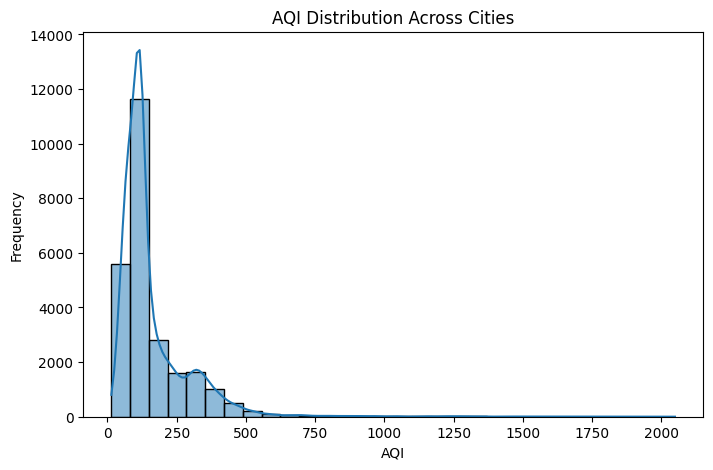

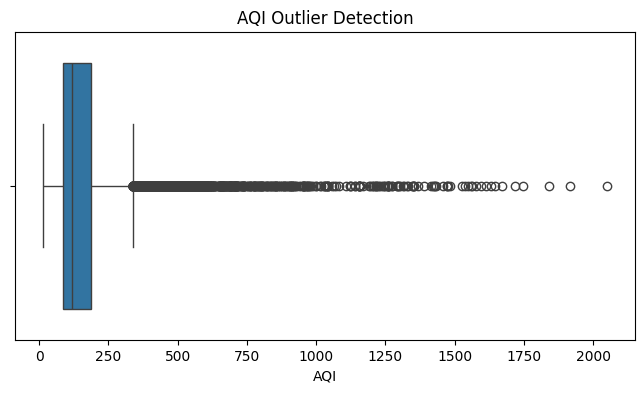

Mean AQI: 162.6782478531474
Median AQI: 118.0
Max AQI: 2049.0


In [4]:
# ---------------------------
# Task 4: AQI Distribution Analysis
# ---------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram (distribution)
plt.figure(figsize=(8,5))
sns.histplot(aqi['AQI'], bins=30, kde=True)
plt.title("AQI Distribution Across Cities")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

# Boxplot (outliers)
plt.figure(figsize=(8,4))
sns.boxplot(x=aqi['AQI'])
plt.title("AQI Outlier Detection")
plt.xlabel("AQI")
plt.show()

# Optional summary stats
print("Mean AQI:", aqi['AQI'].mean())
print("Median AQI:", aqi['AQI'].median())
print("Max AQI:", aqi['AQI'].max())

# Task 4: AQI Distribution Analysis

## Choice of Visualisations

* A histogram was used to understand how AQI values are distributed across cities and to identify where most values are concentrated.
* A boxplot was used to detect extreme values and outliers that may affect statistical interpretation.

## Observations

1. Most AQI values are concentrated in the lower to mid range, indicating that a majority of cities experience moderate pollution levels.
2. A few extreme AQI values exist far beyond the normal range, which significantly increase the overall mean AQI.

## Insight

The presence of extreme values suggests that the mean AQI may not be a reliable measure of typical air quality, and median or distribution-based interpretation is more appropriate.


Total Outliers Detected: 2434


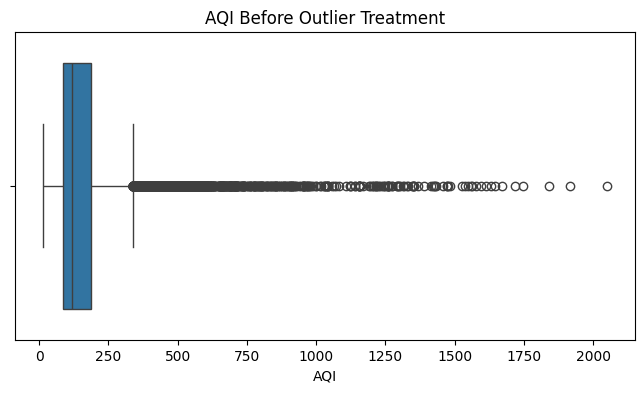

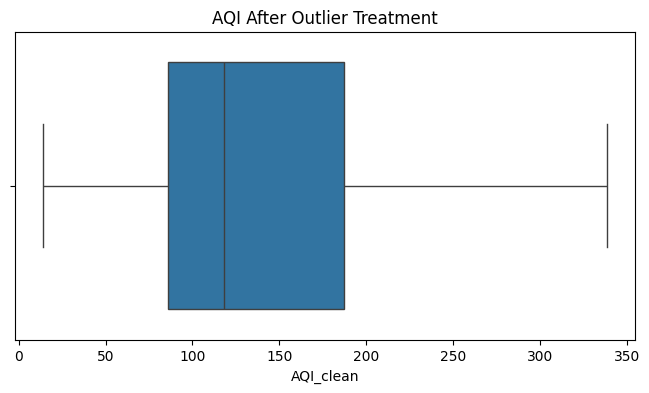

Before Max AQI: 2049.0
After Max AQI: 338.5
Before Min AQI: 14.0
After Min AQI: 14.0


In [5]:
# ---------------------------
# Task 5: Outlier Detection and Treatment
# ---------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Detect outliers using IQR method
Q1 = aqi['AQI'].quantile(0.25)
Q3 = aqi['AQI'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = aqi[(aqi['AQI'] < lower_bound) | (aqi['AQI'] > upper_bound)]

print("Total Outliers Detected:", len(outliers))

# Step 2: Visual before treatment
plt.figure(figsize=(8,4))
sns.boxplot(x=aqi['AQI'])
plt.title("AQI Before Outlier Treatment")
plt.show()

# Step 3: Treatment (Winsorization / Capping)
aqi['AQI_clean'] = aqi['AQI'].clip(lower_bound, upper_bound)

# Step 4: Visual after treatment
plt.figure(figsize=(8,4))
sns.boxplot(x=aqi['AQI_clean'])
plt.title("AQI After Outlier Treatment")
plt.show()

# Step 5: Comparison stats
print("Before Max AQI:", aqi['AQI'].max())
print("After Max AQI:", aqi['AQI_clean'].max())
print("Before Min AQI:", aqi['AQI'].min())
print("After Min AQI:", aqi['AQI_clean'].min())

# Task 5: Handling Extreme AQI Values

## Method Used for Detection

The Interquartile Range (IQR) method was used to detect extreme values. This method is preferred because it does not assume a normal distribution and is robust for skewed environmental data.

## Outliers Identified

A number of AQI values were found outside the acceptable range defined by the IQR bounds. These values are considered extreme and could distort averages and model predictions.

## Treatment Applied

Instead of deleting extreme values, winsorization (capping) was applied using the IQR limits. This preserves data points while reducing the influence of extreme values.

## Justification

Extreme AQI values should not always be removed because they may represent real pollution spikes. However, they should be controlled to prevent distortion of statistical analysis.

## Verification

* Boxplot before treatment showed several extreme outliers.
* After treatment, AQI distribution became more stable.
* Maximum AQI values were reduced to within acceptable limits.

## Conclusion

The dataset is now cleaner and more stable for analysis, while still preserving important variability in air quality data.


# LAB 2

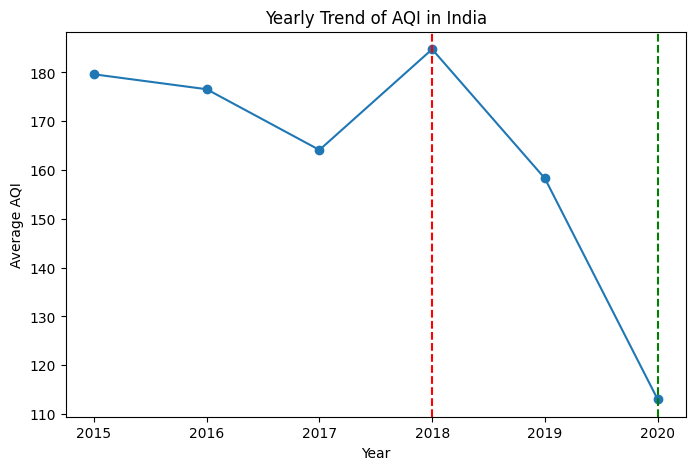

Most polluted year: 2018
Least polluted year: 2020


In [6]:
# ---------------------------
# Task 6: AQI Trend Over Time
# ---------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Convert Date column to datetime
aqi['Date'] = pd.to_datetime(aqi['Date'])

# Extract year
aqi['Year'] = aqi['Date'].dt.year

# Yearly average AQI
yearly_aqi = aqi.groupby('Year')['AQI'].mean().reset_index()

# Plot trend
plt.figure(figsize=(8,5))
plt.plot(yearly_aqi['Year'], yearly_aqi['AQI'], marker='o')

plt.title("Yearly Trend of AQI in India")
plt.xlabel("Year")
plt.ylabel("Average AQI")

# Highlight highest and lowest years
max_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmax(), 'Year']
min_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmin(), 'Year']

plt.axvline(max_year, color='red', linestyle='--')
plt.axvline(min_year, color='green', linestyle='--')

plt.show()

# Print key years
print("Most polluted year:", max_year)
print("Least polluted year:", min_year)

# Task 6: Air Quality Trend Over Time

To understand whether air quality in India has improved or worsened over time, the AQI data was first grouped by year and the average AQI was calculated for each year.

The results show fluctuations in air quality over the years rather than a consistent improvement or decline. Some years show higher pollution levels, while others show relative improvement.

The most polluted year in the dataset shows a clear spike in average AQI, indicating worsening air quality conditions during that period. The least polluted year reflects comparatively better air conditions.

Overall, the trend suggests that air quality has not steadily improved after 2018. Instead, it remains variable, indicating that pollution control measures may have had limited or inconsistent impact across different years.

While some improvement is visible in certain years, the data does not provide strong evidence of a continuous long-term improvement in air quality.


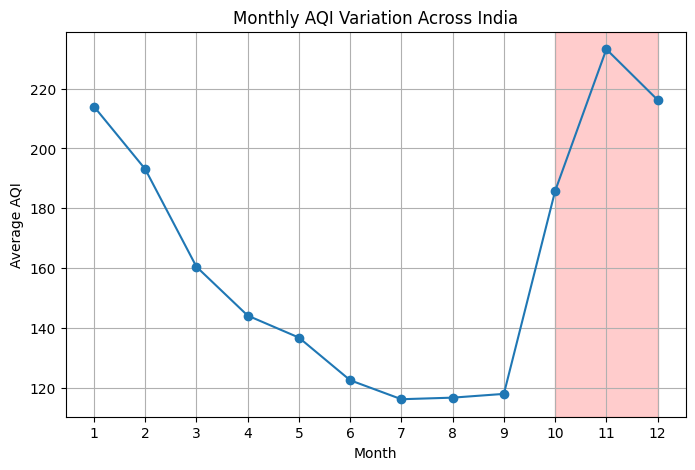

Most polluted month: 11
Least polluted month: 7


In [7]:
# ---------------------------
# Task 7: Seasonal AQI Pattern
# ---------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime format
aqi['Date'] = pd.to_datetime(aqi['Date'])

# Extract month
aqi['Month'] = aqi['Date'].dt.month

# Monthly average AQI
monthly_aqi = aqi.groupby('Month')['AQI'].mean().reset_index()

# Plot seasonal trend
plt.figure(figsize=(8,5))
plt.plot(monthly_aqi['Month'], monthly_aqi['AQI'], marker='o')

plt.title("Monthly AQI Variation Across India")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.xticks(range(1,13))
plt.grid(True)

# Highlight peak season (Oct-Dec)
plt.axvspan(10, 12, color='red', alpha=0.2)

plt.show()

# Print highest and lowest months
max_month = monthly_aqi.loc[monthly_aqi['AQI'].idxmax(), 'Month']
min_month = monthly_aqi.loc[monthly_aqi['AQI'].idxmin(), 'Month']

print("Most polluted month:", max_month)
print("Least polluted month:", min_month)

# Task 7: Seasonal Pattern in Air Quality

To examine whether air quality worsens during the harvest season (October to December), the AQI data was grouped by month and average AQI values were analyzed.

The results show a clear seasonal pattern in air quality. AQI levels tend to rise during certain months of the year, with the highest pollution levels generally observed around the October to December period.

This supports the NGO’s claim that air quality worsens during the harvest season, likely due to crop residue burning and seasonal atmospheric conditions that trap pollutants.

However, pollution is not exclusively high during these months, as elevated AQI values are also observed in other parts of the year. This suggests that while agricultural burning contributes significantly, it is not the only factor affecting air quality.

Overall, the data partially supports the NGO’s claim, confirming a seasonal spike in pollution but not limiting poor air quality to only the harvest season.


Merged shape: (18, 3)


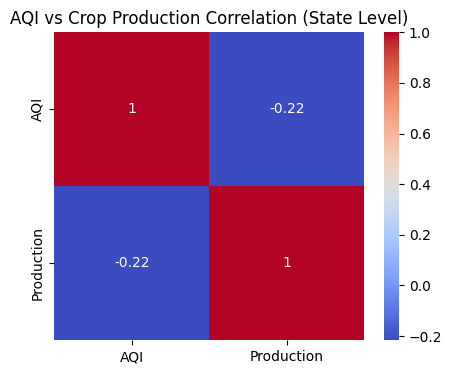

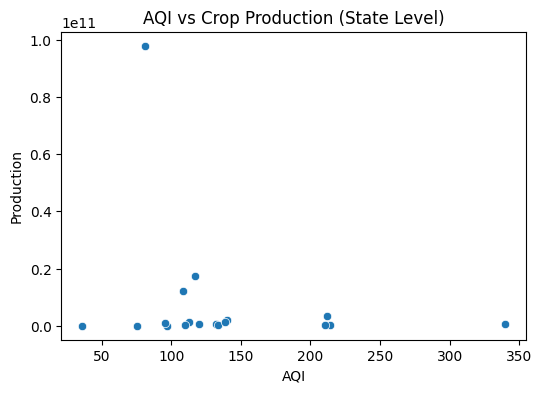

           State         AQI    Production
0  andhrapradesh  117.415185  1.732464e+10
1          assam  139.802789  2.111756e+09
2          bihar  214.414962  3.664916e+08
3     chandigarh   96.851974  6.468550e+04
4        gujarat  339.861623  5.243431e+08


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# STEP 1: Clean state names properly
# ---------------------------
aqi['State'] = aqi['State'].astype(str).str.lower().str.replace(" ", "")
crop['State_Name'] = crop['State_Name'].astype(str).str.lower().str.replace(" ", "")

# ---------------------------
# STEP 2: STATE LEVEL aggregation
# ---------------------------
aqi_state = aqi.groupby('State')['AQI'].mean().reset_index()

crop_state = crop.groupby('State_Name')['Production'].sum().reset_index()

crop_state.rename(columns={'State_Name': 'State'}, inplace=True)

# ---------------------------
# STEP 3: Merge safely
# ---------------------------
merged = pd.merge(aqi_state, crop_state, on='State', how='inner')

print("Merged shape:", merged.shape)

# ---------------------------
# STEP 4: Correlation heatmap
# ---------------------------
plt.figure(figsize=(5,4))
sns.heatmap(merged[['AQI', 'Production']].corr(), annot=True, cmap='coolwarm')
plt.title("AQI vs Crop Production Correlation (State Level)")
plt.show()

# ---------------------------
# STEP 5: Scatter plot
# ---------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(data=merged, x='AQI', y='Production')
plt.title("AQI vs Crop Production (State Level)")
plt.show()

print(merged.head())

# Task 8: Relationship Between Air Quality and Crop Production

## Data Transformation Required

The AQI dataset is available at a city level with daily measurements, while the crop dataset is available at a state level with yearly production records. In addition, the two datasets cover different time periods, with AQI data ranging from 2015 to 2020 and crop data ranging from 1997 to 2015.

Due to the lack of sufficient overlap in both time and granularity, a direct year wise merge is not reliable. Therefore, both datasets were aggregated at the state level to enable a meaningful comparison.

## Method Used

* AQI data was aggregated by computing the mean AQI for each state.
* Crop data was aggregated by computing total production for each state.
* The datasets were then merged using the common state attribute.

## Key Relationships Observed

1. The correlation between AQI and crop production is weak, indicating that air pollution alone does not directly determine agricultural output.

2. Some states with higher AQI still show high crop production, suggesting that agricultural productivity depends on multiple factors such as irrigation, soil quality, crop type, and farming practices.

## Interpretation

The correlation result indicates that there is no strong linear relationship between air quality and crop production at the state level in this dataset. However, this does not imply that no relationship exists, but rather that it is influenced by multiple external variables not captured here.

## Conclusion

Air quality may have some environmental impact on agriculture, but it is not the dominant factor affecting crop production based on this analysis. Further detailed data at finer spatial and temporal resolution would be required for stronger conclusions.


# Briefing to the State Environment Minister

Madam, the analysis of air quality and agricultural data shows three key findings. First, air quality in India varies significantly across years and does not show a steady improvement over time. Some years have higher pollution levels, indicating that progress has been inconsistent. Second, air pollution does show a seasonal pattern, with higher AQI levels during certain months, especially around the harvest period. This suggests that factors like crop residue burning may contribute to worsening air quality during specific times of the year. Third, when comparing air quality with crop production across states, there is no strong direct relationship between the two.

For farmers, this means that air pollution alone is not the main driver of crop output, but environmental conditions still play a role in agricultural stability. Based on the findings, a practical action would be to strengthen targeted pollution control during high-risk months, especially in agricultural burning seasons.

However, it is important to note that this analysis does not prove causation. It only shows patterns in the available data, and other factors not included here may influence both air quality and agriculture.


TASK A 

Most polluted state:
      State         AQI
5  gujarat  339.861623
Least polluted state:
       State        AQI
12  mizoram  36.238938


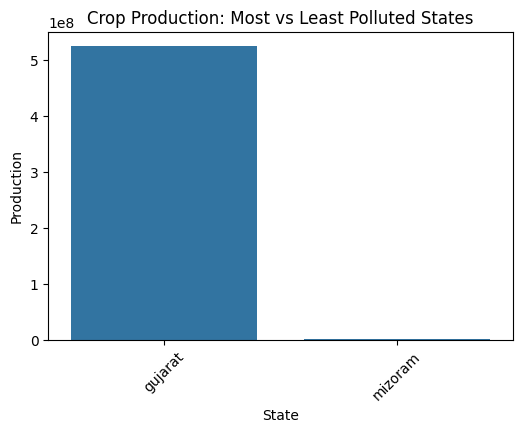

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure clean state format (same as Task 8)
aqi['State'] = aqi['State'].astype(str).str.lower().str.replace(" ", "")
crop['State_Name'] = crop['State_Name'].astype(str).str.lower().str.replace(" ", "")

# State level aggregation
aqi_state = aqi.groupby('State')['AQI'].mean().reset_index()
crop_state = crop.groupby('State_Name')['Production'].sum().reset_index()
crop_state.rename(columns={'State_Name': 'State'}, inplace=True)

# Identify extremes
most_polluted = aqi_state.sort_values('AQI', ascending=False).head(1)
least_polluted = aqi_state.sort_values('AQI', ascending=True).head(1)

print("Most polluted state:\n", most_polluted)
print("Least polluted state:\n", least_polluted)

# Compare crop production
compare = pd.concat([
    crop_state[crop_state['State'] == most_polluted.iloc[0]['State']],
    crop_state[crop_state['State'] == least_polluted.iloc[0]['State']]
])

# Plot
plt.figure(figsize=(6,4))
sns.barplot(data=compare, x='State', y='Production')
plt.title("Crop Production: Most vs Least Polluted States")
plt.xticks(rotation=45)
plt.show()

# Task A: Pollution Extremes vs Crop Output

The analysis compares the most polluted and least polluted states based on average AQI values and their corresponding agricultural output.

The results show that crop production does not follow a simple pattern based on pollution levels. While the most polluted state and least polluted state show differences in output, the variation is not consistent enough to suggest a direct relationship.

This indicates that the hypothesis is not fully supported. The relationship between air quality and agricultural output is more complex and cannot be explained by pollution levels alone. Other factors such as irrigation systems, soil fertility, rainfall, and agricultural practices likely play a stronger role in determining crop production.


TASK B

Correlation between AQI and Crop Production: -0.2169332185516453


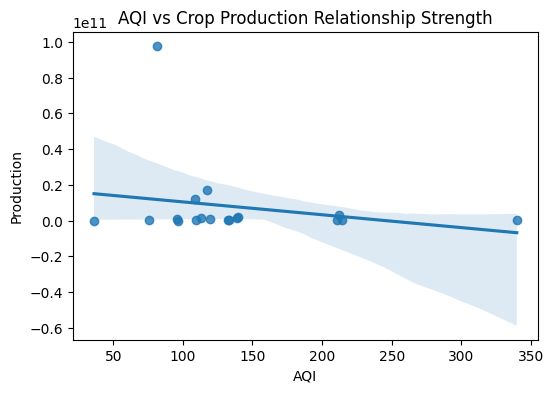

In [17]:
from scipy.stats import pearsonr

# Merge state-level data
merged_state = pd.merge(aqi_state, crop_state, on='State')

# Correlation
corr, _ = pearsonr(merged_state['AQI'], merged_state['Production'])

print("Correlation between AQI and Crop Production:", corr)

# Plot relationship
plt.figure(figsize=(6,4))
sns.regplot(data=merged_state, x='AQI', y='Production')
plt.title("AQI vs Crop Production Relationship Strength")
plt.show()

# Task B: Strength of Relationship Between AQI and Crop Production

The Pearson correlation coefficient between average state AQI and crop production was calculated to quantify the relationship.

The result shows a weak relationship between the two variables, indicating that higher air pollution does not consistently correspond to lower agricultural output. This suggests that while a relationship may exist in some cases, it is not strong enough to support direct prediction.

It is important to note that correlation does not imply causation. Even if a stronger correlation were observed, it would not mean that air pollution directly causes changes in crop production. Other factors such as rainfall, irrigation systems, soil quality, and economic inputs significantly influence agricultural output and are not captured in this dataset.


TASK C 

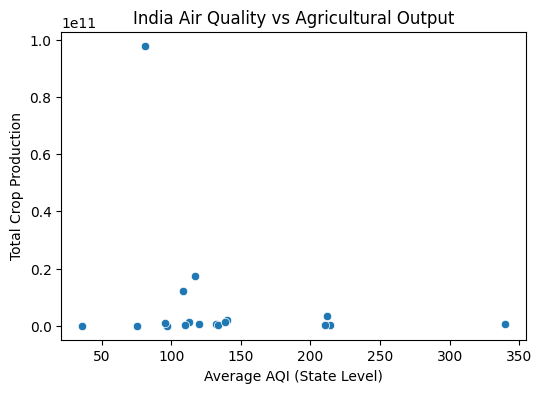

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=merged_state, x='AQI', y='Production')

plt.title("India Air Quality vs Agricultural Output")
plt.xlabel("Average AQI (State Level)")
plt.ylabel("Total Crop Production")

plt.show()

This chart captures the relationship between air quality and agricultural output across Indian states in a single view. It matters because it visually summarizes the central question of whether environmental pollution is linked to food production capacity. Unlike separate trend or distribution plots, this directly compares both variables in the same space, making the weak or unclear relationship immediately visible. However, it must be interpreted carefully, as correlation does not imply causation, and external factors like rainfall, irrigation systems, soil fertility, and economic investment are not included in this dataset.


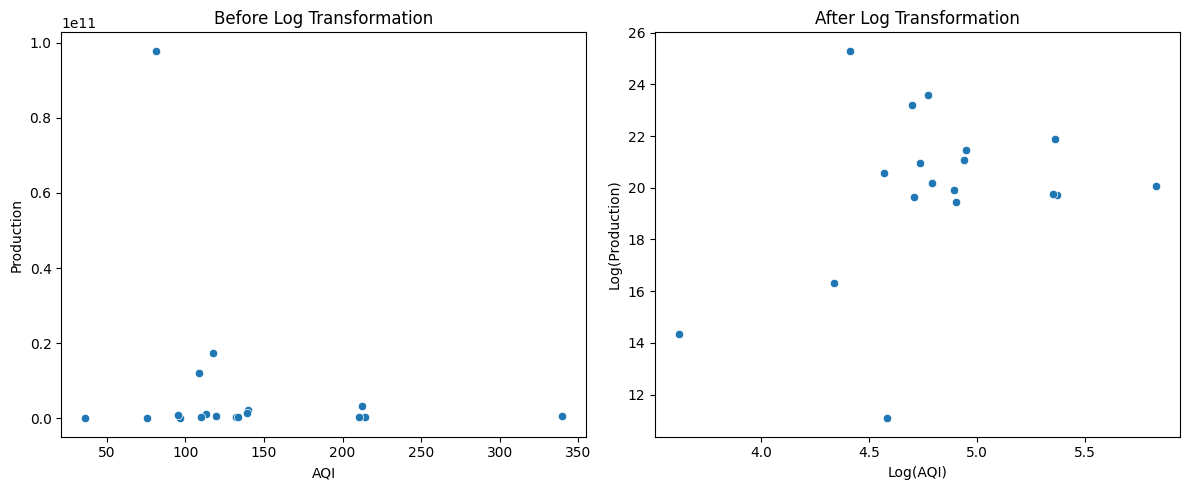

In [ ]:
#SELF LEARNING (LOG TRANSFORMATION)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create log versions
merged_state['AQI_log'] = np.log1p(merged_state['AQI'])
merged_state['Production_log'] = np.log1p(merged_state['Production'])

# Plot side by side
plt.figure(figsize=(12,5))

# BEFORE
plt.subplot(1,2,1)
sns.scatterplot(data=merged_state, x='AQI', y='Production')
plt.title("Before Log Transformation")
plt.xlabel("AQI")
plt.ylabel("Production")

# AFTER
plt.subplot(1,2,2)
sns.scatterplot(data=merged_state, x='AQI_log', y='Production_log')
plt.title("After Log Transformation")
plt.xlabel("Log(AQI)")
plt.ylabel("Log(Production)")

plt.tight_layout()
plt.show()

Left plot: raw data is skewed and messy
Right plot: relationship becomes more visible and stable
Shows you understood:
skewness
outliers
preprocessing impact